In [1]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]
df = df[(constant.JPSI_MASS-50 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+50)]

In [2]:
best_vertex_df, _ = filter_duplicates_by_performance(
    df, "Bplus_ENDVERTEX_CHI2", "min"
)

best_pidk_df, _ = filter_duplicates_by_performance(
    df, "Kplus_PIDK", "max"
)

In [3]:
def create_significance_plot(
    df: pd.DataFrame,
    cut_column: str,
    cut_range: tuple[float, float],
    cut_side: str,
    signal_column: str,
    signal_range: tuple[float, float],
    sideband_ranges: tuple,
):
    """
    Creates a significance plot based on cuts applied to one column and yields calculated from another.

    Parameters:
        df (pd.DataFrame): Input data containing signal and sideband columns.
        cut_column (str): Column to apply the cuts on (e.g., Kplus_PIDK).
        cut_range (np.ndarray): Range of cut values to iterate over.
        cut_side (str): Cut "above" or "below".
        signal_column (str): Column used to define signal and sideband regions (e.g., Bplus_mass).
        signal_range (tuple): Tuple (min, max) defining the signal region in `signal_column`.
        sideband_ranges (list of tuples): List of (min, max) ranges for the sidebands in `signal_column`.

    Returns:
        tuple: (cut_range, significance_list)
    """
    significance_list = []
    signal_width = signal_range[1] - signal_range[0]

    # Calculate total sideband width
    total_sideband_width = sum(sb[1] - sb[0] for sb in sideband_ranges)
    if total_sideband_width <= 0:
        raise ValueError("Total sideband width must be greater than zero.")

    for cut in cut_range:
        # Apply cut
        if cut_side.lower() == "below":
            filtered_data = df[df[cut_column] < cut]
        elif cut_side.lower() == "above":
            filtered_data = df[df[cut_column] > cut]
        else:
            raise ValueError("Argument 'cut_side' must be 'above' or 'below'")

        # Signal yield
        signal = filtered_data[
            (filtered_data[signal_column] >= signal_range[0])
            & (filtered_data[signal_column] <= signal_range[1])
        ]
        signal_yield = len(signal)

        # Background yield (scaled from sidebands)
        background_yield = 0
        for sb_range in sideband_ranges:
            sideband = filtered_data[
                (filtered_data[signal_column] >= sb_range[0])
                & (filtered_data[signal_column] <= sb_range[1])
            ]
            background_yield += len(sideband)

        # Scale background yield to signal width
        background_yield_scaled = background_yield * (
            signal_width / total_sideband_width
        )

        # Calculate significance
        if signal_yield + background_yield_scaled > 0:
            significance = signal_yield / np.sqrt(
                signal_yield + background_yield_scaled
            )
        else:
            significance = 0

        significance_list.append(significance)

    return cut_range, significance_list

In [9]:
# Define the signal and sideband ranges for Bplus_mass
signal_range = (5230, 5330)
sideband_ranges = [(5150, 5230), (5330, 5400)]

# Create the significance plot
cut_values, significance = create_significance_plot(
    df,
    cut_column='Bplus_ENDVERTEX_CHI2',
    cut_range = np.linspace(0, 15, 100),
    cut_side="below",
    signal_column='Bplus_M',
    signal_range=signal_range,
    sideband_ranges=sideband_ranges,
)

fig, ax = plt.subplots()

ax.plot(cut_values, significance)
ax.set(ylabel="Signficance", xlabel="Bplus_ENDVERTEX_CHI2")
ax.set_ylim(bottom=0)

KeyError: 'Bplus_ENDVERTEX_CHI2'

   Kplus_PIDK   Bplus_mass
0    4.764052  5288.924545
1    3.400157  5292.818625
2    3.978738  5332.989788
3    5.240893  5319.657912
4    4.867558  5319.203946


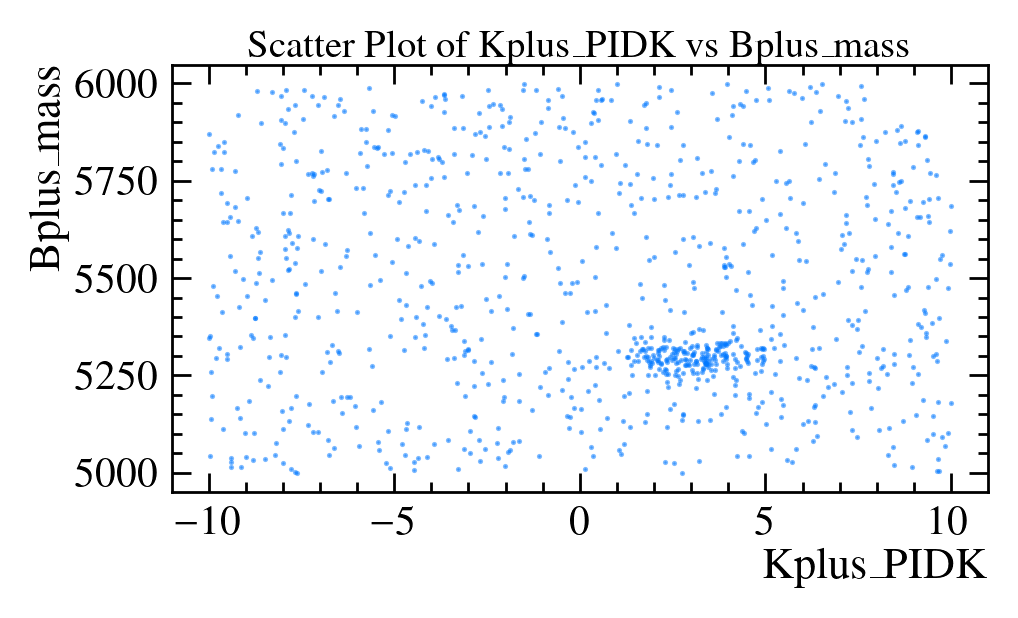

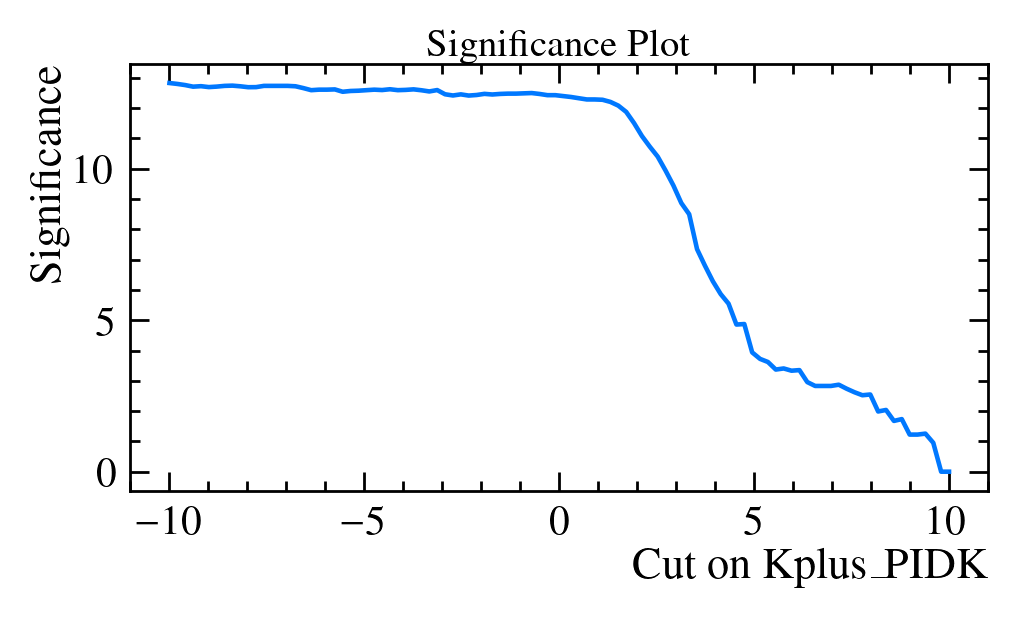

In [5]:
import pandas as pd
import numpy as np

# Create a sample dataset with a clear signal and background
np.random.seed(0)  # For reproducibility

n_signal = 200
n_background = 800

# Signal data centered around specific Kplus_PIDK and Bplus_mass range
signal_Kplus_PIDK = np.random.normal(loc=3, scale=1, size=n_signal)
signal_Bplus_mass = np.random.normal(loc=5300, scale=30, size=n_signal)

# Background data spread out across the entire range
background_Kplus_PIDK = np.random.uniform(-10, 10, n_background)
background_Bplus_mass = np.random.uniform(5000, 6000, n_background)

# Combine signal and background into one dataset
Kplus_PIDK = np.concatenate((signal_Kplus_PIDK, background_Kplus_PIDK))
Bplus_mass = np.concatenate((signal_Bplus_mass, background_Bplus_mass))

# Create DataFrame
df = pd.DataFrame({
    'Kplus_PIDK': Kplus_PIDK,
    'Bplus_mass': Bplus_mass
})

# Display first few rows of the dataset
print(df.head())


import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Kplus_PIDK'], df['Bplus_mass'], alpha=0.5, s=3)
plt.xlabel('Kplus_PIDK')
plt.ylabel('Bplus_mass')
plt.title('Scatter Plot of Kplus_PIDK vs Bplus_mass')
plt.show()


# Define the parameters for the significance plot function
cut_column = 'Kplus_PIDK'
cut_range = np.linspace(-10, 10, 100)
cut_side = 'above'  # or 'below', depending on the cuts you want to test
signal_column = 'Bplus_mass'
signal_range = (5270, 5330)  # Adjusted range for signal
sideband_ranges = [(5000, 5100), (5500, 5600)]  # Example ranges for sidebands

# Call the significance plot function
cut_range, significance_list = create_significance_plot(df, cut_column, cut_range, cut_side, signal_column, signal_range, sideband_ranges)

# Plot the significance
plt.figure(figsize=(10, 6))
plt.plot(cut_range, significance_list)
plt.xlabel(f'Cut on {cut_column}')
plt.ylabel('Significance')
plt.title('Significance Plot')
plt.show()
